# 🌊 BinWaves Duke (Reconstrction)

> **Inputs:**
> - Bathymetry file in `.nc` format, located in the `inputs/` folder.  
> - `Kp_coefficients.nc` file obtained with the `Propagation Notebook`.
> 
>
> **Outputs:**
> 
> 

### BinWaves Notebooks Overview

This Jupyter Notebook is the first of three in the **BinWaves** modeling workflow, following Cagigal et al., 2024 :

1. `BinWaves_Propagation.ipynb`  
2. `BinWaves_Reconstruction.ipynb`  
3. `BinWaves_Validation.ipynb`

---

#### Before You Start

Make sure you have:

- Installed the latest version of `bluemath-tk`:  
  ```bash
  pip install bluemath-tk[waves]
  ```
 
---

<details>
<summary><strong>📁 BinWaves_Propagation.ipynb</strong></summary>

This notebook constructs and runs the **library of pre-run cases** for all **monochromatic wave systems**.

</details>

---

<details open>
<summary><strong>📁 BinWaves_Reconstruction.ipynb</strong></summary>

This notebook reconstructs **wave conditions** using **offshore directional wave spectra**.

##### Requirements:

- Offshore wave spectrum data (e.g., **CAWCR** or **ERA5** datasets).

- **OPTIONAL 1**: Apply **satellite corrections** to the hindcast spectrum before running BinWaves using the `CalVal` tool in the BlueMath toolkit. An example is provided in the Jupyter Notebook **P00A_CalVal_Carolinas_CAWCR_4469.ipynb**.

- **OPTIONAL 2**: A **Super Point Spectrum** can be also used as input to the hindcast spectrum before running BinWaves. The `SuperPoint` aggregates the energy from a number of points (Wave Spectra) surrounding the study site (Cagigal et al., 2021).  An example is provided in the Jupyter Notebook **Super Point Computation** .

</details>

---

<details>
<summary><strong>📁 BinWaves_Validation.ipynb</strong></summary>

This notebook performs **validation** using **wave buoy data**, if available.

##### Requirements:

- Wave buoy data in a format compatible with BinWaves (if available).
- Some wave buoy data can be freely downloaded from:  
  🌊 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

- **NOTE:** You can use the `NDBC_buoy_data.ipynb` notebook to:
  - Download the buoy data.
  - Convert it into the appropriate format for BinWaves.

</details>

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import xarray as xr

whacs_spectra = xr.open_dataset("inputs/alejandria_spec_WHACS.nc").rename(
    {"__xarray_dataarray_variable__": "efth"}
)
whacs_spectra

<xarray.Dataset> Size: 5MB
Dimensions:   (time: 744, freq: 28, dir: 30)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * freq      (freq) float64 224B 0.04118 0.0453 0.04983 ... 0.4908 0.5399
  * dir       (dir) float64 240B 84.0 72.0 60.0 48.0 ... 132.0 120.0 108.0 96.0
    seapoint  int32 4B ...
Data variables:
    efth      (time, freq, dir) float64 5MB ...

In [3]:
# Load all the gridded kps and reproject

kp_coeffs = xr.open_dataset("outputs/kp_coefficients.nc")
kp_coeffs

<xarray.Dataset> Size: 90MB
Dimensions:   (case_num: 420, site: 32, freq: 28, dir: 30)
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 413 414 415 416 417 418 419
  * site      (site) int64 256B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31 32
  * freq      (freq) float64 224B 0.0412 0.0453 0.0498 ... 0.4462 0.4908 0.5399
  * dir       (dir) float64 240B 12.0 24.0 36.0 48.0 ... 324.0 336.0 348.0 360.0
    lat       float64 8B ...
    lon       float64 8B ...
    coord_x   (site) float64 256B ...
    coord_y   (site) float64 256B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 90MB ...

In [4]:
import pandas as pd
from utils.operations import transform_Offshore_spectrum

model_parameters = pd.read_csv("ALEXANDRIA_CASES/swan_cases.csv").to_dict(orient="list")

# Load interest spectra

offshore_spectra, offshore_spectra_case = transform_Offshore_spectrum(
    spectrum=whacs_spectra.sortby("dir"),
    subset_parameters=model_parameters,
    available_case_num=kp_coeffs.case_num.values,
)
offshore_spectra_case

<xarray.DataArray 'efth' (case_num: 420, time: 744)> Size: 2MB
array([[4.07158166e-26, 2.32611070e-27, 1.12874679e-28, ...,
        1.00664002e-78, 1.10562194e-53, 3.81396107e-45],
       [3.04427337e-20, 8.84972760e-21, 2.07698368e-21, ...,
        5.57539051e-55, 2.56205574e-42, 6.34829370e-33],
       [2.68973294e-16, 2.37551839e-16, 1.63609901e-16, ...,
        7.90192855e-39, 1.27493544e-34, 1.21437156e-24],
       ...,
       [5.21681706e-05, 5.15994552e-05, 3.49013360e-05, ...,
        1.21948982e-04, 1.15871745e-04, 1.06915002e-04],
       [3.26101922e-05, 3.22702053e-05, 2.18525414e-05, ...,
        7.61302424e-05, 7.23460593e-05, 6.67678726e-05],
       [2.03412951e-05, 2.01358354e-05, 1.36462711e-05, ...,
        4.74453863e-05, 4.50911669e-05, 4.16204400e-05]], shape=(420, 744))
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 413 414 415 416 417 418 419
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
    seapoint  int32 4B 2011723

In [5]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

time_to_reconstruct = "2020-01-20"

# Reconstruct spectra
reconstructed_onshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra_case.sel(time=time_to_reconstruct),
    kp_coeffs=kp_coeffs,
)
reconstructed_onshore_spectra

<xarray.Dataset> Size: 5MB
Dimensions:   (site: 32, freq: 28, dir: 30, time: 24)
Coordinates:
  * site      (site) int64 256B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31 32
  * freq      (freq) float64 224B 0.0412 0.0453 0.0498 ... 0.4462 0.4908 0.5399
  * dir       (dir) float64 240B 12.0 24.0 36.0 48.0 ... 324.0 336.0 348.0 360.0
  * time      (time) datetime64[ns] 192B 2020-01-20 ... 2020-01-20T23:00:00
    lat       float64 8B 0.0
    lon       float64 8B 0.0
    coord_x   (site) float64 256B 28.6 29.22 29.83 30.44 ... 29.9 30.17 30.44
    coord_y   (site) float64 256B 30.6 30.6 30.6 30.6 ... 31.38 31.49 31.59
    seapoint  int32 4B 2011723
Data variables:
    kps       (time, site, freq, dir) float64 5MB 0.0 0.0 ... 2.85e-05 2.012e-05

In [6]:
reconstructed_onshore_spectra

<xarray.Dataset> Size: 5MB
Dimensions:   (site: 32, freq: 28, dir: 30, time: 24)
Coordinates:
  * site      (site) int64 256B 1 2 3 4 5 6 7 8 9 ... 24 25 26 27 28 29 30 31 32
  * freq      (freq) float64 224B 0.0412 0.0453 0.0498 ... 0.4462 0.4908 0.5399
  * dir       (dir) float64 240B 12.0 24.0 36.0 48.0 ... 324.0 336.0 348.0 360.0
  * time      (time) datetime64[ns] 192B 2020-01-20 ... 2020-01-20T23:00:00
    lat       float64 8B 0.0
    lon       float64 8B 0.0
    coord_x   (site) float64 256B 28.6 29.22 29.83 30.44 ... 29.9 30.17 30.44
    coord_y   (site) float64 256B 30.6 30.6 30.6 30.6 ... 31.38 31.49 31.59
    seapoint  int32 4B 2011723
Data variables:
    kps       (time, site, freq, dir) float64 5MB 0.0 0.0 ... 2.85e-05 2.012e-05

(<Figure size 1500x600 with 2 Axes>,
 <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

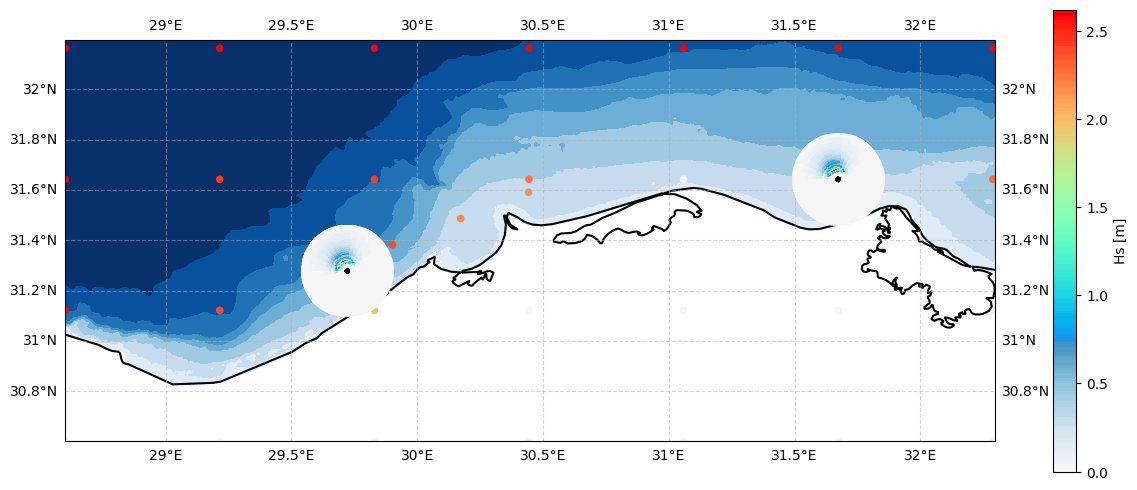

In [7]:
from utils.plotting import plot_spectrum_in_coastline

time_to_plot = "2020-01-20 12:00"

# Plot the spectrum along the coastline
bathy = xr.open_dataset("inputs/EMODNET_alexandria.nc").elevation
plot_spectrum_in_coastline(
    bathy=bathy,
    reconstructed_onshore_spectra=reconstructed_onshore_spectra.rename({"kps": "kp"}),
    reconstruction_kps=kp_coeffs,
    offshore_spectra=offshore_spectra,
    time_to_plot=time_to_plot,
    sites_for_spectrum=[19, 28],
)

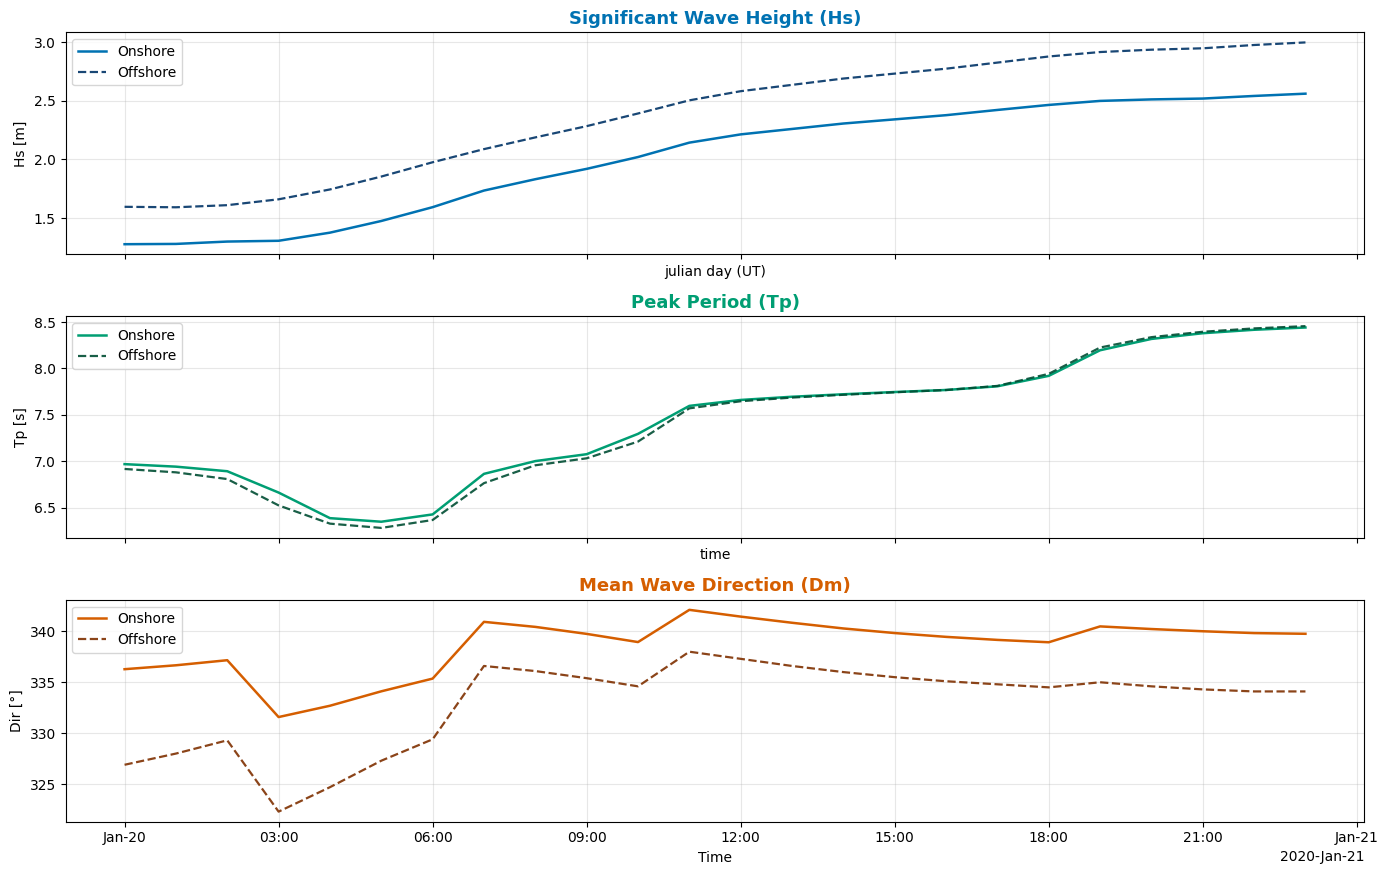

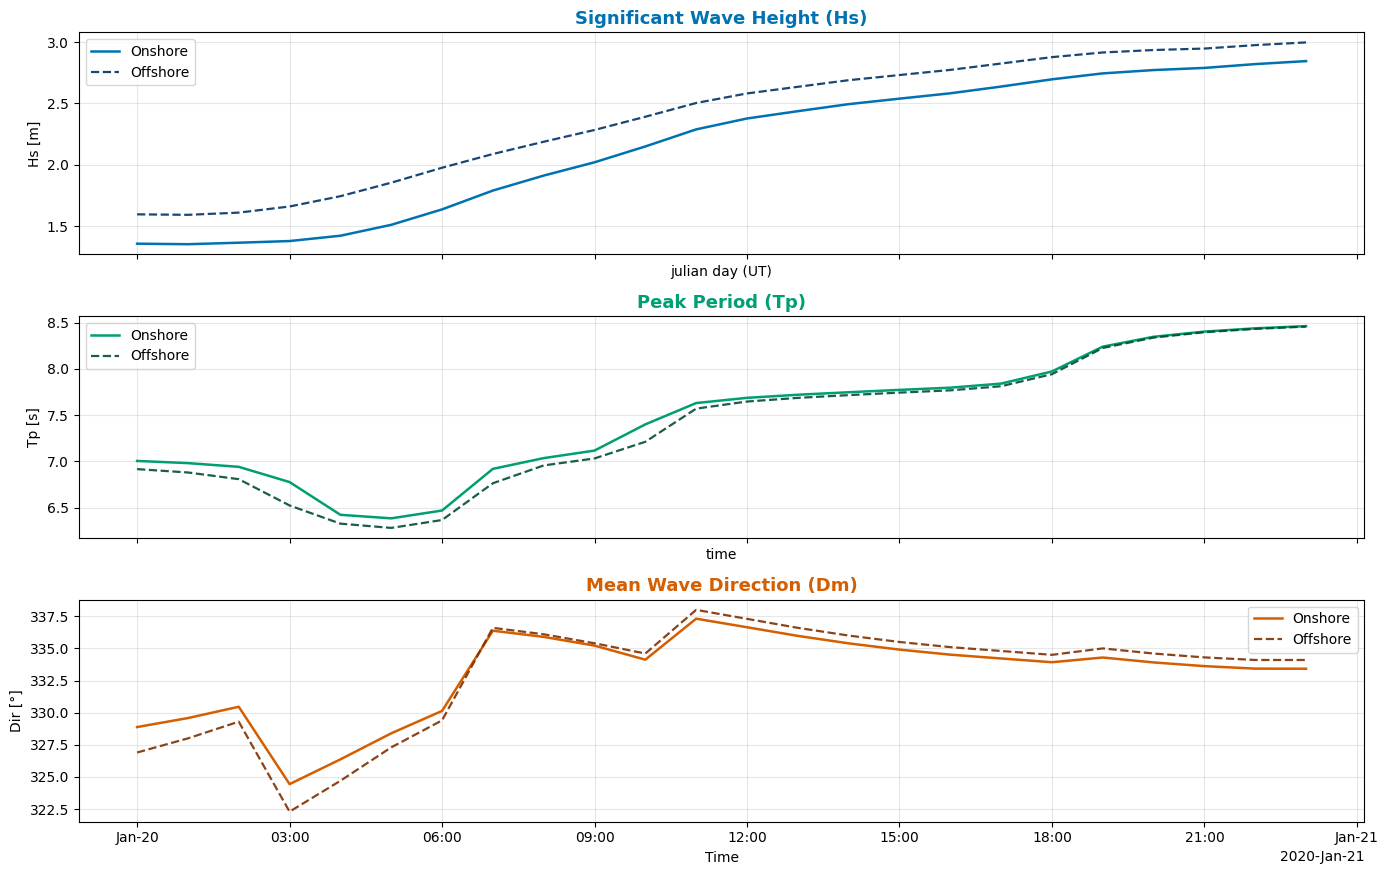

(<Figure size 1400x900 with 3 Axes>,
 array([<Axes: title={'center': 'Significant Wave Height (Hs)'}, xlabel='julian day (UT)', ylabel='Hs [m]'>,
        <Axes: title={'center': 'Peak Period (Tp)'}, xlabel='time', ylabel='Tp [s]'>,
        <Axes: title={'center': 'Mean Wave Direction (Dm)'}, xlabel='Time', ylabel='Dir [°]'>],
       dtype=object))

In [ ]:
from utils.plotting import plot_wave_parameters

plot_wave_parameters(
    onshore_spectra=reconstructed_onshore_spectra,
    offshore_spectra=offshore_spectra.sel(
        time=reconstructed_onshore_spectra.time.values, method="nearest"
    ),
    site=19,
    title_prefix=None,
)

plot_wave_parameters(
    onshore_spectra=reconstructed_onshore_spectra,
    offshore_spectra=offshore_spectra.sel(
        time=reconstructed_onshore_spectra.time.values, method="nearest"
    ),
    site=28,
    title_prefix=None,
)